# 1. Loading in files and creating objects to work with

In [4]:
# import necassary packages

import pandas as pd

In [8]:
# read in data and clean up the dataset if necessary

data_BGCs = pd.read_csv(
    'data_BGCs+activity.csv',
    index_col = 'Pseud',
)

In [10]:
# check the file

data_BGCs

,DAPG,pseudomonine,pyoverdine,activity_Fusarium
Pseud,,,,
1,1,0,0,1
2,0,0,0,0
3,0,0,1,0
4,0,0,0,0
5,0,0,0,0
6,0,0,1,0
7,0,1,1,0
8,1,0,0,1
9,0,1,1,0


In [12]:
data_inh = pd.read_csv(
    'data_inhibition_zones.csv',
)

In [14]:
# check the file

data_inh

,species,condition,TR,Pseud1,Pseud8,Pseud10,Pseud11
0,FS,A,1,4,2,2,0
1,FS,A,1,3,5,2,0
2,FS,A,1,3,2,2,0
3,FS,A,2,5,6,3,0
4,FS,A,2,4,4,1,0
5,FS,A,2,3,6,2,0
6,FS,B,1,2,4,2,0
7,FS,B,1,3,3,2,0
8,FS,B,1,3,3,2,0
9,FS,B,2,4,6,3,0


In [16]:
# create a new object for each species + condition for further work

FS_A = data_inh[(data_inh['species'] == 'FS') & (data_inh['condition'] == 'A')]
FS_B = data_inh[(data_inh['species'] == 'FS') & (data_inh['condition'] == "B")]
FC_A = data_inh[(data_inh['species'] == 'FC') & (data_inh['condition'] == 'A')]
FC_B = data_inh[(data_inh['species'] == 'FC') & (data_inh['condition'] == "B")]
FO_A = data_inh[(data_inh['species'] == 'FO') & (data_inh['condition'] == 'A')]
FO_B = data_inh[(data_inh['species'] == 'FO') & (data_inh['condition'] == "B")]
FG_A = data_inh[(data_inh['species'] == 'FG') & (data_inh['condition'] == 'A')]
FG_B = data_inh[(data_inh['species'] == 'FG') & (data_inh['condition'] == "B")]

In [18]:
# store the dataset in a list

datasets_stats = {'FS_A': FS_A, 'FS_B': FS_B, 
            'FC_A': FC_A, 'FC_B': FC_B,
            'FG_A': FG_A, 'FG_B': FG_B,
            'FO_A': FO_A, 'FO_B': FO_B
           }

In [20]:
# create a dictionary which stores all the columns of interest in in each dataset

columns_to_compare_stats = {
    'FS_A': ['Pseud1', 'Pseud8', 'Pseud10'],
    'FS_B': ['Pseud1', 'Pseud8', 'Pseud10'],
    'FC_A': ['Pseud1', 'Pseud8', 'Pseud10'],
    'FC_B': ['Pseud1', 'Pseud8', 'Pseud10'],
    'FG_A': ['Pseud1', 'Pseud8', 'Pseud10'],
    'FG_B': ['Pseud1', 'Pseud8', 'Pseud10'],
    'FO_A': ['Pseud1', 'Pseud8', 'Pseud10'],
    'FO_B': ['Pseud1', 'Pseud8', 'Pseud10'],
}

# 2. Checking if the data is normally distributed

At the moment, I don't have enough data points to check normal distribution by histogram or Q-Q plots, so I am currently using Shapiro-Wilk test. This script uses preliminary data from my experiments, and soon I will be able to add more data points and check the normal distribution of my data. I expect my data to be normally distributed, so this script includes parametric statistical tests, however, if my data turns out to be not normally distributed, I will switch to non-parametric alternatives for statistical tests.  

In [24]:
# import necessary packages

import numpy as np
import scipy.stats as stats

# loop to apply the Shapiro-Wilk test for normality on all datasets and columns
for dataset_name, dataset in datasets_stats.items():
    print(f"Checking normality for dataset: {dataset_name}")

    for column in columns_to_compare_stats[dataset_name]:
        data = dataset[column]

        # Shapiro-Wilk test
        stat, p_value = stats.shapiro(data)

        # print the result
        
        print(f"Column: {column}")
        print(f"Shapiro-Wilk Test Statistic: {stat:.4f}, P-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print("Result: The data is NOT normally distributed (reject H0).\n")
        else:
            print("Result: The data is normally distributed (fail to reject H0).\n")

Checking normality for dataset: FS_A
Column: Pseud1
Shapiro-Wilk Test Statistic: 0.8216, P-value: 0.0911
Result: The data is normally distributed (fail to reject H0).

Column: Pseud8
Shapiro-Wilk Test Statistic: 0.8502, P-value: 0.1579
Result: The data is normally distributed (fail to reject H0).

Column: Pseud10
Shapiro-Wilk Test Statistic: 0.8268, P-value: 0.1010
Result: The data is normally distributed (fail to reject H0).

Checking normality for dataset: FS_B
Column: Pseud1
Shapiro-Wilk Test Statistic: 0.8216, P-value: 0.0911
Result: The data is normally distributed (fail to reject H0).

Column: Pseud8
Shapiro-Wilk Test Statistic: 0.8606, P-value: 0.1912
Result: The data is normally distributed (fail to reject H0).

Column: Pseud10
Shapiro-Wilk Test Statistic: 0.8268, P-value: 0.1010
Result: The data is normally distributed (fail to reject H0).

Checking normality for dataset: FC_A
Column: Pseud1
Shapiro-Wilk Test Statistic: 0.9580, P-value: 0.8043
Result: The data is normally dist

C:\Users\shakirovaa\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


# t test to see if there is difference between conditions for each species

In [26]:
# create pairs of datasets which will be compared 

dataset_pairs = [
    ('FS_A', 'FS_B'),
    ('FC_A', 'FC_B'),
    ('FG_A', 'FG_B'),
    ('FO_A', 'FO_B')
]

# loop through dataset pairs and apply t test to each pair of datasets

for pair in dataset_pairs:
    dataset1_name, dataset2_name = pair
    dataset1 = datasets_stats[dataset1_name]
    dataset2 = datasets_stats[dataset2_name]
    
    columns1 = columns_to_compare_stats[dataset1_name]
    columns2 = columns_to_compare_stats[dataset2_name]
    
    for col1, col2 in zip(columns1, columns2):
       # t test
        stat, p_value = stats.ttest_ind(dataset1[col1], dataset2[col2], equal_var=False)  # Use equal_var=False for Welch's t-test

        # print the results
        print(f"Comparing {dataset1_name} ({col1}) with {dataset2_name} ({col2})")
        print(f"T-Test Statistic: {stat:.4f}")
        print(f"P-Value: {p_value:.4f}")

        if p_value < 0.05:
            print(f"{dataset1_name} vs {dataset2_name}: The means are significantly different (reject H0).")
        else:
            print(f"{dataset1_name} vs {dataset2_name}: The means are NOT significantly different (fail to reject H0).")
        print("-" * 50)

Comparing FS_A (Pseud1) with FS_B (Pseud1)
T-Test Statistic: 0.7071
P-Value: 0.4956
FS_A vs FS_B: The means are NOT significantly different (fail to reject H0).
--------------------------------------------------
Comparing FS_A (Pseud8) with FS_B (Pseud8)
T-Test Statistic: -0.3558
P-Value: 0.7300
FS_A vs FS_B: The means are NOT significantly different (fail to reject H0).
--------------------------------------------------
Comparing FS_A (Pseud10) with FS_B (Pseud10)
T-Test Statistic: 0.0000
P-Value: 1.0000
FS_A vs FS_B: The means are NOT significantly different (fail to reject H0).
--------------------------------------------------
Comparing FC_A (Pseud1) with FC_B (Pseud1)
T-Test Statistic: 0.2270
P-Value: 0.8255
FC_A vs FC_B: The means are NOT significantly different (fail to reject H0).
--------------------------------------------------
Comparing FC_A (Pseud8) with FC_B (Pseud8)
T-Test Statistic: 4.4448
P-Value: 0.0015
FC_A vs FC_B: The means are significantly different (reject H0).


# ANOVA to see if there is difference between species

In [28]:
# letters A or B in dataset name indicate the condition
# now the goal is to compare difference between species
# to do this, filter all datasets with A and B in the name into 2 different groups

datasets_A = {k: v for k, v in datasets_stats.items() if 'A' in k}
datasets_B = {k: v for k, v in datasets_stats.items() if 'B' in k}

## Difference between species for condition A

In [31]:
# check that datasets filtered correctly

datasets_A

{'FS_A':   species condition  TR  Pseud1  Pseud8  Pseud10  Pseud11
 0      FS         A   1       4       2        2        0
 1      FS         A   1       3       5        2        0
 2      FS         A   1       3       2        2        0
 3      FS         A   2       5       6        3        0
 4      FS         A   2       4       4        1        0
 5      FS         A   2       3       6        2        0,
 'FC_A':    species condition  TR  Pseud1  Pseud8  Pseud10  Pseud11
 36      FC         A   1       5      11        5        2
 37      FC         A   1       7       9        4        1
 38      FC         A   1       5       9        4        2
 39      FC         A   2       4       9        7        3
 40      FC         A   2       8      10        5        1
 41      FC         A   2       6       7        4        2,
 'FG_A':    species condition  TR  Pseud1  Pseud8  Pseud10  Pseud11
 24      FG         A   1       2       6        0        0
 25      FG         A

In [33]:
# define columns from datasets which will be compared in ANOVA

columns_to_compare_ANOVA = ['Pseud1', 'Pseud8', 'Pseud10']

# define function to perform ANOVA and loop through all defined columns and datasets

def perform_anova_across_datasets(datasets, column):
    data = [dataset[column] for dataset in datasets]
    
    f_stat, p_value = stats.f_oneway(*data)
    
    return f_stat, p_value

for column in columns_to_compare_ANOVA:
    print(f"ANOVA for {column}")
    
    datasets = [dataset for dataset in datasets_A.values()]

    f_stat, p_value = perform_anova_across_datasets(datasets, column)
    
    # print the results
    print(f"  F-Statistic: {f_stat:.4f}, P-Value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"    The means for {column} are significantly different (reject H0).")
    else:
        print(f"    The means for {column} are not significantly different (fail to reject H0).")
    
    print("-" * 50)

ANOVA for Pseud1
  F-Statistic: 8.2432, P-Value: 0.0009
    The means for Pseud1 are significantly different (reject H0).
--------------------------------------------------
ANOVA for Pseud8
  F-Statistic: 20.5376, P-Value: 0.0000
    The means for Pseud8 are significantly different (reject H0).
--------------------------------------------------
ANOVA for Pseud10
  F-Statistic: 25.1282, P-Value: 0.0000
    The means for Pseud10 are significantly different (reject H0).
--------------------------------------------------


## Difference between species for condition B

In [35]:
# check that datasets filtered correctly

datasets_B

{'FS_B':    species condition  TR  Pseud1  Pseud8  Pseud10  Pseud11
 6       FS         B   1       2       4        2        0
 7       FS         B   1       3       3        2        0
 8       FS         B   1       3       3        2        0
 9       FS         B   2       4       6        3        0
 10      FS         B   2       4       6        2        0
 11      FS         B   2       4       5        1        0,
 'FC_B':    species condition  TR  Pseud1  Pseud8  Pseud10  Pseud11
 42      FC         B   1       4       7        4        0
 43      FC         B   1       6       7        5        0
 44      FC         B   1       6       7        4        0
 45      FC         B   2       5       5        5        0
 46      FC         B   2       7       5        3        0
 47      FC         B   2       6       6        2        0,
 'FG_B':    species condition  TR  Pseud1  Pseud8  Pseud10  Pseud11
 30      FG         B   1       2       5        1        0
 31      FG   

In [39]:
# define columns from datasets which will be compared in ANOVA

columns_to_compare_ANOVA = ['Pseud1', 'Pseud8', 'Pseud10']

# define function to perform ANOVA and loop through all defined columns and datasets

def perform_anova_across_datasets(datasets, column):
    data = [dataset[column] for dataset in datasets]
    
    f_stat, p_value = stats.f_oneway(*data)
    
    return f_stat, p_value

for column in columns_to_compare_ANOVA:
    print(f"ANOVA for {column}")
    
    datasets = [dataset for dataset in datasets_B.values()]

    f_stat, p_value = perform_anova_across_datasets(datasets, column)
    
    # print the results
    print(f"  F-Statistic: {f_stat:.4f}, P-Value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"    The means for {column} are significantly different (reject H0).")
    else:
        print(f"    The means for {column} are not significantly different (fail to reject H0).")
    
    print("-" * 50)

ANOVA for Pseud1
  F-Statistic: 10.6637, P-Value: 0.0002
    The means for Pseud1 are significantly different (reject H0).
--------------------------------------------------
ANOVA for Pseud8
  F-Statistic: 9.8949, P-Value: 0.0003
    The means for Pseud8 are significantly different (reject H0).
--------------------------------------------------
ANOVA for Pseud10
  F-Statistic: 12.0567, P-Value: 0.0001
    The means for Pseud10 are significantly different (reject H0).
--------------------------------------------------


# Tukey HSD Test

In [41]:
# import all necessary packages

import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## For condition A

In [43]:
# here, perform ANOVA again, and where it indicates significant difference,
# apply Tuckey HSD test

# perform ANOVA

def perform_anova_across_datasets(datasets, column):
    data = [dataset[column] for dataset in datasets]
    
    f_stat, p_value = stats.f_oneway(*data)
    
    return f_stat, p_value

# define function to perform Tukey HSD Test

def perform_tukey_hsd_test(datasets, column):
    # create a data frame for Tukey's test input
    all_data = []
    labels = []
    
    for dataset_name, dataset in datasets.items():
        data = dataset[column]
        all_data.extend(data)
        labels.extend([dataset_name] * len(data))
    
    df = pd.DataFrame({'value': all_data, 'dataset': labels})
    
    # perform Tukey HSD Test
    tukey = pairwise_tukeyhsd(df['value'], df['dataset'], alpha=0.05)
    return tukey

# loop through each column to perform ANOVA and Tukey HSD for all datasets
for column in columns_to_compare_ANOVA:
    print(f"ANOVA for {column}")
    
    # collect all datasets for ANOVA
    datasets = [dataset for dataset in datasets_A.values()]
    
    # perform ANOVA across all datasets
    f_stat, p_value = perform_anova_across_datasets(datasets, column)
    
    # print the ANOVA result
    print(f"  F-Statistic: {f_stat:.4f}, P-Value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"    The means for {column} are significantly different (reject H0).")
        print("    Running Tukey's HSD Test...\n")
        
        # perform Tukey HSD Test for pairwise comparisons
        tukey_result = perform_tukey_hsd_test(datasets_A, column)
        print(tukey_result.summary())
    else:
        print(f"    The means for {column} are not significantly different (fail to reject H0).")
    
    print("-" * 50)

ANOVA for Pseud1
  F-Statistic: 8.2432, P-Value: 0.0009
    The means for Pseud1 are significantly different (reject H0).
    Running Tukey's HSD Test...

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  FC_A   FG_A     -3.5 0.0005 -5.5064 -1.4936   True
  FC_A   FO_A     -1.5 0.1896 -3.5064  0.5064  False
  FC_A   FS_A  -2.1667 0.0314 -4.1731 -0.1602   True
  FG_A   FO_A      2.0 0.0509 -0.0064  4.0064  False
  FG_A   FS_A   1.3333 0.2762 -0.6731  3.3398  False
  FO_A   FS_A  -0.6667 0.7893 -2.6731  1.3398  False
----------------------------------------------------
--------------------------------------------------
ANOVA for Pseud8
  F-Statistic: 20.5376, P-Value: 0.0000
    The means for Pseud8 are significantly different (reject H0).
    Running Tukey's HSD Test...

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
--

## For condition B

In [45]:
def perform_anova_across_datasets(datasets, column):
    data = [dataset[column] for dataset in datasets]
    
    f_stat, p_value = stats.f_oneway(*data)
    
    return f_stat, p_value

def perform_tukey_hsd_test(datasets, column):

    all_data = []
    labels = []
    
    for dataset_name, dataset in datasets.items():
        data = dataset[column]
        all_data.extend(data)
        labels.extend([dataset_name] * len(data))
    
    df = pd.DataFrame({'value': all_data, 'dataset': labels})
    
    tukey = pairwise_tukeyhsd(df['value'], df['dataset'], alpha=0.05)
    return tukey

for column in columns_to_compare_ANOVA:
    print(f"ANOVA for {column}")
    
    datasets = [dataset for dataset in datasets_B.values()]

    f_stat, p_value = perform_anova_across_datasets(datasets, column)

    print(f"  F-Statistic: {f_stat:.4f}, P-Value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"    The means for {column} are significantly different (reject H0).")
        print("    Running Tukey's HSD Test...\n")
        
        # Perform Tukey HSD Test for pairwise comparisons
        tukey_result = perform_tukey_hsd_test(datasets_B, column)
        print(tukey_result.summary())
    else:
        print(f"    The means for {column} are not significantly different (fail to reject H0).")
    
    print("-" * 50)

ANOVA for Pseud1
  F-Statistic: 10.6637, P-Value: 0.0002
    The means for Pseud1 are significantly different (reject H0).
    Running Tukey's HSD Test...

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  FC_B   FG_B     -3.0 0.0002 -4.5681 -1.4319   True
  FC_B   FO_B     -1.5 0.0639 -3.0681  0.0681  False
  FC_B   FS_B  -2.3333 0.0025 -3.9015 -0.7652   True
  FG_B   FO_B      1.5 0.0639 -0.0681  3.0681  False
  FG_B   FS_B   0.6667   0.64 -0.9015  2.2348  False
  FO_B   FS_B  -0.8333 0.4631 -2.4015  0.7348  False
----------------------------------------------------
--------------------------------------------------
ANOVA for Pseud8
  F-Statistic: 9.8949, P-Value: 0.0003
    The means for Pseud8 are significantly different (reject H0).
    Running Tukey's HSD Test...

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
--

# Bar charts

In [47]:
# prepare datasets for creating bar charts

datasets_graphA = {'FS_A': FS_A,
            'FC_A': FC_A,
            'FG_A': FG_A,
            'FO_A': FO_A,
           }

In [49]:
datasets_graphB = {'FS_B': FS_B, 
            'FC_B': FC_B,
            'FG_B': FG_B,
            'FO_B': FO_B
           }

In [51]:
# select columns from the datasets which will be plotted

columns_graph = ['Pseud1', 'Pseud8', 'Pseud10']

In [57]:
# import all necessary packages

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Comparing all species in one condition: condition A

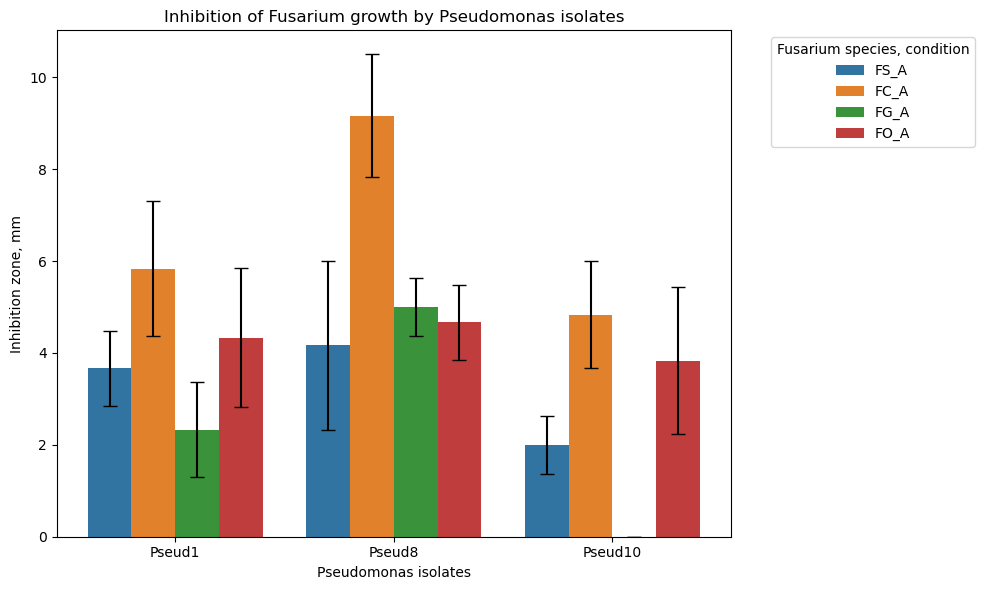

In [59]:
# prepare data for plotting
data_for_plotting_A = []

# loop through each dataset and calculate the mean and standard deviation for each column

for dataset_name, dataset in datasets_graphA.items():
    for column in columns_graph:
        mean_value = dataset[column].mean()
        std_value = dataset[column].std()
        
        # append the dataset name, column name, mean, and standard deviation to the list
        data_for_plotting_A.append({
            'Dataset': dataset_name,
            'Column': column,
            'Mean': mean_value,
            'SD': std_value
        })

# convert the data to the data frame
plot_data_A = pd.DataFrame(data_for_plotting_A)

# set up the matplotlib figure
plt.figure(figsize=(10, 6))

# create the bar plot
ax = sns.barplot(x='Column', y='Mean', hue='Dataset', data=plot_data_A)

# add error bars
for i, dataset_name in enumerate(datasets_graphA.keys()):
    for j, column in enumerate(columns_graph):
        # get the correct position for each bar
        bar_position = ax.patches[i * len(columns_graph) + j].get_x() + ax.patches[i * len(columns_graph) + j].get_width() / 2
        # get the corresponding mean and standard deviation
        mean_value = plot_data_A[(plot_data_A['Dataset'] == dataset_name) & (plot_data_A['Column'] == column)]['Mean'].values[0]
        std_value = plot_data_A[(plot_data_A['Dataset'] == dataset_name) & (plot_data_A['Column'] == column)]['SD'].values[0]
        # add the error bar at the correct position
        ax.errorbar(bar_position, mean_value, yerr=std_value, fmt='none', color='black', capsize=5)

# customise the plot
plt.title('Inhibition of Fusarium growth by Pseudomonas isolates')
plt.ylabel('Inhibition zone, mm')
plt.xlabel('Pseudomonas isolates')
plt.legend(title='Fusarium species, condition', bbox_to_anchor=(1.05, 1), loc='upper left')

# show the plot
plt.tight_layout()
plt.show()

## Comparing all species in one condition: condition B

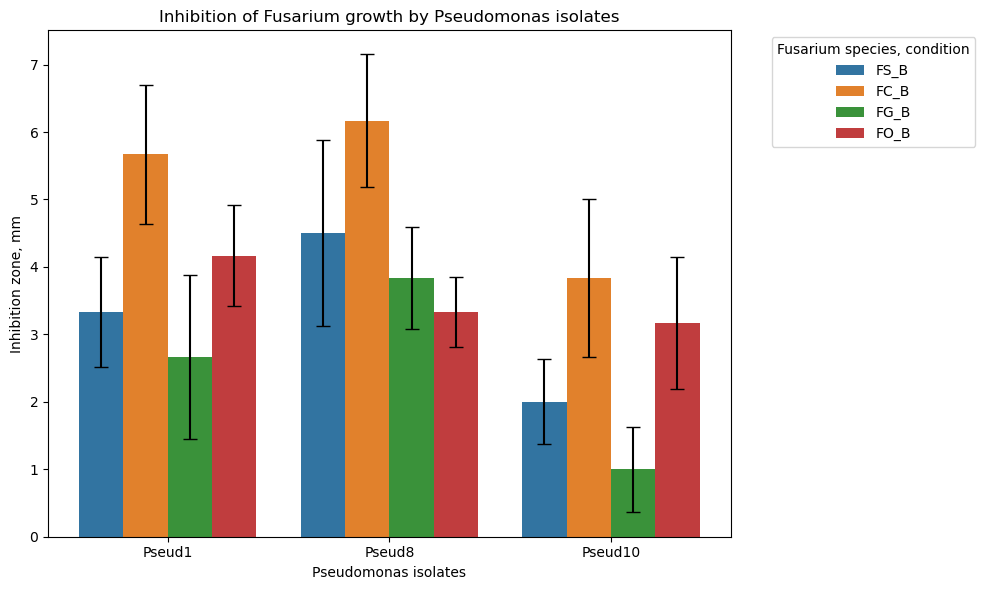

In [63]:
data_for_plotting_B = []

for dataset_name, dataset in datasets_graphB.items():
    for column in columns_graph:
        mean_value = dataset[column].mean()
        std_value = dataset[column].std()
        
        data_for_plotting_B.append({
            'Dataset': dataset_name,
            'Column': column,
            'Mean': mean_value,
            'SD': std_value
        })

plot_data_B = pd.DataFrame(data_for_plotting_B)

plt.figure(figsize=(10, 6))

ax = sns.barplot(x='Column', y='Mean', hue='Dataset', data=plot_data_B)

for i, dataset_name in enumerate(datasets_graphB.keys()):
    for j, column in enumerate(columns_graph):
        bar_position = ax.patches[i * len(columns_graph) + j].get_x() + ax.patches[i * len(columns_graph) + j].get_width() / 2
        mean_value = plot_data_B[(plot_data_B['Dataset'] == dataset_name) & (plot_data_B['Column'] == column)]['Mean'].values[0]
        std_value = plot_data_B[(plot_data_B['Dataset'] == dataset_name) & (plot_data_B['Column'] == column)]['SD'].values[0]
        ax.errorbar(bar_position, mean_value, yerr=std_value, fmt='none', color='black', capsize=5)

plt.title('Inhibition of Fusarium growth by Pseudomonas isolates')
plt.ylabel('Inhibition zone, mm')
plt.xlabel('Pseudomonas isolates')
plt.legend(title='Fusarium species, condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Comparison within species for two different conditions: FS

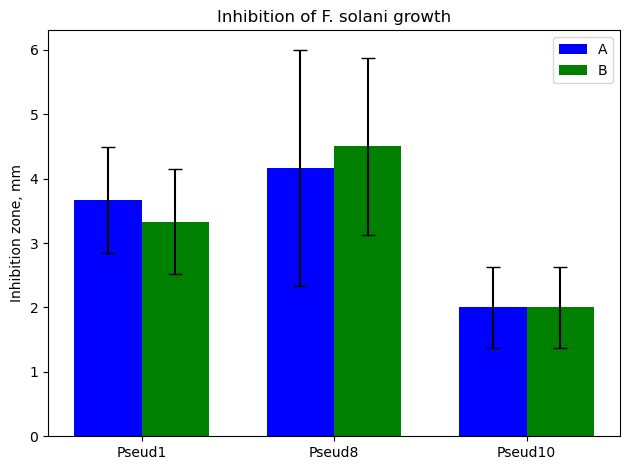

In [107]:
# calculate mean and standard deviation for the selected columns
mean_FS_A = FS_A[columns_graph].mean()
std_FS_A = FS_A[columns_graph].std()

mean2_FS_B = FS_B[columns_graph].mean()
std2_FS_B = FS_B[columns_graph].std()

# create bar chart
bar_width = 0.35
index = np.arange(len(columns_graph))

# plot for the first dataset
plt.bar(index, mean_FS_A, bar_width, yerr=std_FS_A, capsize=5, label='A', color='blue')

# plot for the second dataset
plt.bar(index + bar_width, mean2_FS_B, bar_width, yerr=std2_FS_B, capsize=5, label='B', color='green')

# customise the plot
plt.ylabel('Inhibition zone, mm')
plt.title('Inhibition of F. solani growth')
plt.xticks(index + bar_width / 2, columns_graph)
plt.legend()

# show the plot
plt.tight_layout()
plt.show()

## Comparing all species in one condition: FO

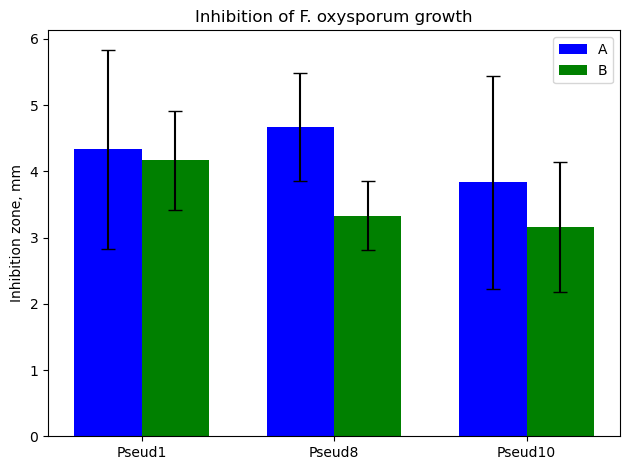

In [65]:
mean_FO_A = FO_A[columns_graph].mean()
std_FO_A= FO_A[columns_graph].std()

mean2_FO_B = FO_B[columns_graph].mean()
std2_FO_B = FO_B[columns_graph].std()

bar_width = 0.35
index = np.arange(len(columns_graph))

plt.bar(index, mean_FO_A, bar_width, yerr=std_FO_A, capsize=5, label='A', color='blue')

plt.bar(index + bar_width, mean2_FO_B, bar_width, yerr=std2_FO_B, capsize=5, label='B', color='green')

plt.ylabel('Inhibition zone, mm')
plt.title('Inhibition of F. oxysporum growth')
plt.xticks(index + bar_width / 2, columns_graph)
plt.legend()

plt.tight_layout()
plt.show()

## Comparing all species in one condition: FG

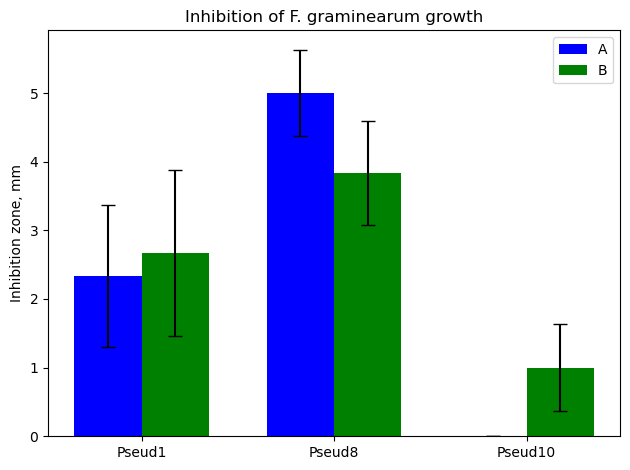

In [111]:
mean_FG_A = FG_A[columns_graph].mean()
std_FG_A = FG_A[columns_graph].std()

mean2_FG_B = FG_B[columns_graph].mean()
std2_FG_B = FG_B[columns_graph].std()

bar_width = 0.35
index = np.arange(len(columns_graph))

plt.bar(index, mean_FG_A, bar_width, yerr=std_FG_A, capsize=5, label='A', color='blue')

plt.bar(index + bar_width, mean2_FG_B, bar_width, yerr=std2_FG_B, capsize=5, label='B', color='green')

plt.ylabel('Inhibition zone, mm')
plt.title('Inhibition of F. graminearum growth')
plt.xticks(index + bar_width / 2, columns_graph)
plt.legend()

plt.tight_layout()
plt.show()

## Comparing all species in one condition: FC

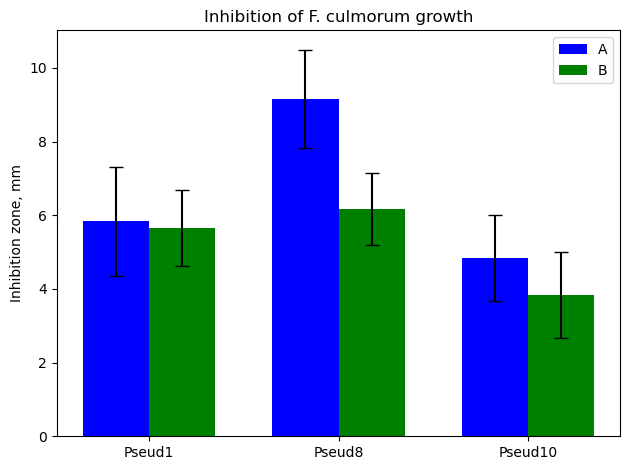

In [113]:
mean_FC_A = FC_A[columns_graph].mean()
std_FC_A = FC_A[columns_graph].std()

mean2_FC_B = FC_B[columns_graph].mean()
std2_FC_B = FC_B[columns_graph].std()

bar_width = 0.35
index = np.arange(len(columns_graph))

plt.bar(index, mean_FC_A, bar_width, yerr=std_FC_A, capsize=5, label='A', color='blue')

plt.bar(index + bar_width, mean2_FC_B, bar_width, yerr=std2_FC_B, capsize=5, label='B', color='green')

plt.ylabel('Inhibition zone, mm')
plt.title('Inhibition of F. culmorum growth')
plt.xticks(index + bar_width / 2, columns_graph)
plt.legend()

plt.tight_layout()
plt.show()

# Relation of BGCs to antifungal activity

I want to see if there is correlation between the presence of certain BGCs in the genome and antifungal activity.
Because my data is binomial, I am performing a Chi-Square test.

In [79]:
# import all necessary packages

from scipy.stats import chi2_contingency
from math import sqrt

# define the columns to compare
cluster_BGCs = data_BGCs[["DAPG", "pseudomonine", "pyoverdine"]]
activity_BGCs = data_BGCs[["activity_Fusarium"]]

# create a loop to run the Chi-Square test
for cluster in cluster_BGCs.columns:
    # create a contingency table
    contingency_table = pd.crosstab(data_BGCs[cluster], data_BGCs[activity])

    # Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # calculate the Phi Coefficient
    n = contingency_table.values.sum()  # Total observations
    phi_coefficient = sqrt(chi2 / n)

    # print the results
    print(f"Comparing '{cluster}' with '{activity}':")
    print(f"Chi-Square Statistic: {chi2:.4f}, P-value: {p:.4f}")
    print(f"Phi Coefficient: {phi_coefficient:.4f}\n")

    if p < 0.05:
        print("Result is significant\n")
    else:
        print("Result is NOT significant\n")

Comparing 'DAPG' with 'activity_Fusarium':
Chi-Square Statistic: 3.9327, P-value: 0.0474
Phi Coefficient: 0.5979

Result is significant

Comparing 'pseudomonine' with 'activity_Fusarium':
Chi-Square Statistic: 0.1364, P-value: 0.7119
Phi Coefficient: 0.1114

Result is NOT significant

Comparing 'pyoverdine' with 'activity_Fusarium':
Chi-Square Statistic: 0.1604, P-value: 0.6888
Phi Coefficient: 0.1208

Result is NOT significant



## Model based on activity against Fusarium

In [81]:
# import necessary packages

import statsmodels.api as sm

In [83]:
# create a new column for the count of 1 (Y for yes - BGC present in the genome) across the first three columns
data_BGCs['count_of_Y'] = data_BGCs[['DAPG', 'pyoverdine', 'pseudomonine']].sum(axis=1)

# define the predictor (count_of_Y) and the response (activity_Fusarium)
X = sm.add_constant(data_BGCs['count_of_Y']) 
y = data_BGCs['activity_Fusarium']

# fit the logistic regression model
model = sm.Logit(y, X).fit()

# print the summary of the model
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.650179
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      activity_Fusarium   No. Observations:                   11
Model:                          Logit   Df Residuals:                        9
Method:                           MLE   Df Model:                            1
Date:                Mon, 13 Jan 2025   Pseudo R-squ.:                0.008089
Time:                        18:57:27   Log-Likelihood:                -7.1520
converged:                       True   LL-Null:                       -7.2103
Covariance Type:            nonrobust   LLR p-value:                    0.7327
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8584      1.096     -0.783      0.434      -3.007       1.291
count_of_Y     0.3218      0.

This model fits badly to the data:
The pseudo R^2 value (0.008089) is very low, which means that the model does not explain much of the variability in activity against Fusarium.
The LLR p-value (0.7327) suggests that the model doesn't provide a significantly better fit than a null model.
p-value for intercept is high (0.434), indicating that it's not statistically significant.
The coefficient of count_of_Y suggests a positive association of number of BGCs with activity against Fusarium, but p-value is too high for it to be significant (0.734). 
All in all, there isn't evidence to say that the number of BGCs in the genome was associated with activity against Fusarium.